# Evaluation & Testing 
Evaluation for each of the model 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pickle

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
import os 

# 1. Loading Hog features and label

In [10]:
HOG_DIR = os.path.join('data', 'features_hog')
PROCESSED_DIR = os.path.join('data', 'processed')

In [11]:
X_test = np.load(os.path.join(HOG_DIR, 'X_test_hog.npy'))
y_test = np.load(os.path.join(HOG_DIR, 'y_test.npy'))

In [12]:
class_names = np.load(os.path.join(PROCESSED_DIR, 'class_names.npy'), allow_pickle=True)
class_names = [str(cls) for cls in class_names]

print(f"Data successfully loaded.")
print(f"Test features shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}\n")

Data successfully loaded.
Test features shape: (960, 1764)
Test labels shape: (960,)



# 2. Evaluation for each model
## 2.1 KNN (K-Nearest-Neighbour)

In [18]:
import joblib

In [19]:
knn_model = joblib.load('model_saved/knn_hangul_model.pkl')

In [20]:
y_pred_knn = knn_model.predict(X_test)

In [21]:
print("\n[KNN Classification Report]:")
print(classification_report(y_test, y_pred_knn, target_names=class_names))


[KNN Classification Report]:
              precision    recall  f1-score   support

           a       0.94      1.00      0.97        15
         bak       1.00      1.00      1.00        15
          bo       1.00      1.00      1.00        15
          bu       1.00      1.00      1.00        15
        choe       1.00      1.00      1.00        15
          da       0.94      1.00      0.97        15
         dae       1.00      0.93      0.97        15
        deul       1.00      1.00      1.00        15
          do       0.88      1.00      0.94        15
        dong       0.88      0.93      0.90        15
           e       0.93      0.93      0.93        15
          eo       0.74      0.93      0.82        15
          eu       1.00      1.00      1.00        15
         eui       1.00      1.00      1.00        15
         eul       0.94      1.00      0.97        15
         eun       0.88      0.93      0.90        15
          ga       0.94      1.00      0.97        

In [22]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

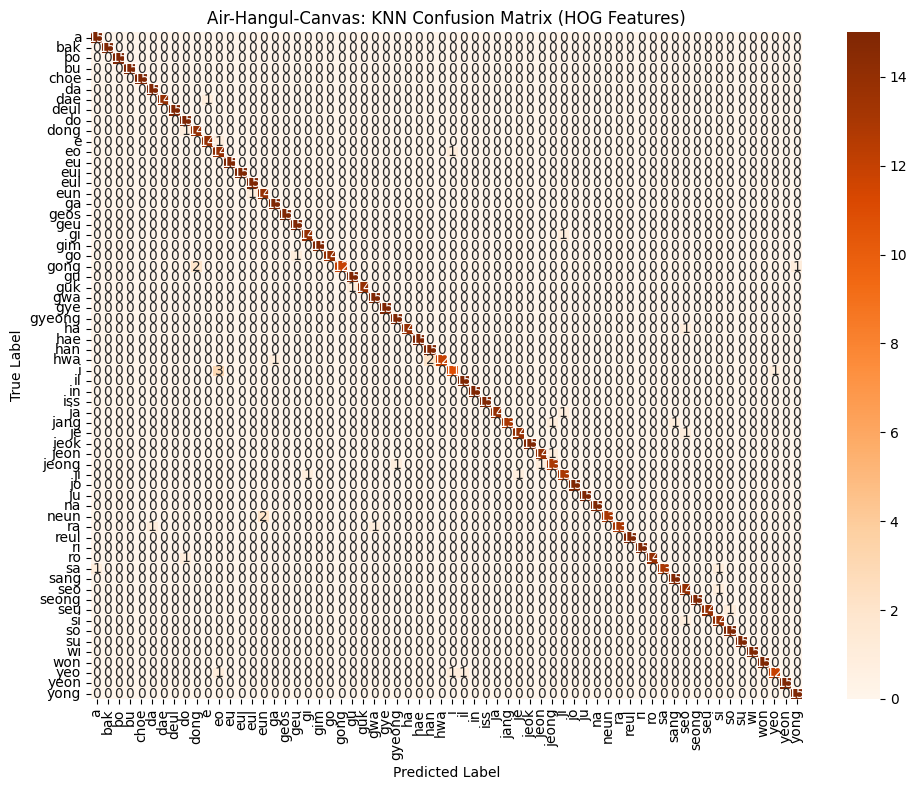

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Air-Hangul-Canvas: KNN Confusion Matrix (HOG Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('evaluation_knn_confusion_matrix.png', dpi=300)
plt.show()

## 2.2 LIGHTGBM CLASSIFIER (LGBM)

In [25]:
lgbm_model = joblib.load('model_saved/lgbm_hangul_model.pkl')

In [26]:
y_pred_lgbm = lgbm_model.predict(X_test)

c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Computer Vision\AOL\Air-Writing-Hangul\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [27]:
print("\n[LightGBM Classification Report]:")
print(classification_report(y_test, y_pred_lgbm, target_names=class_names))


[LightGBM Classification Report]:
              precision    recall  f1-score   support

           a       0.83      1.00      0.91        15
         bak       0.93      0.87      0.90        15
          bo       0.94      1.00      0.97        15
          bu       0.93      0.87      0.90        15
        choe       0.93      0.93      0.93        15
          da       1.00      0.93      0.97        15
         dae       0.93      0.87      0.90        15
        deul       1.00      0.93      0.97        15
          do       0.93      0.93      0.93        15
        dong       0.81      0.87      0.84        15
           e       0.93      0.93      0.93        15
          eo       0.72      0.87      0.79        15
          eu       0.93      0.93      0.93        15
         eui       0.93      0.87      0.90        15
         eul       0.81      0.87      0.84        15
         eun       0.92      0.80      0.86        15
          ga       1.00      0.93      0.97   

In [28]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

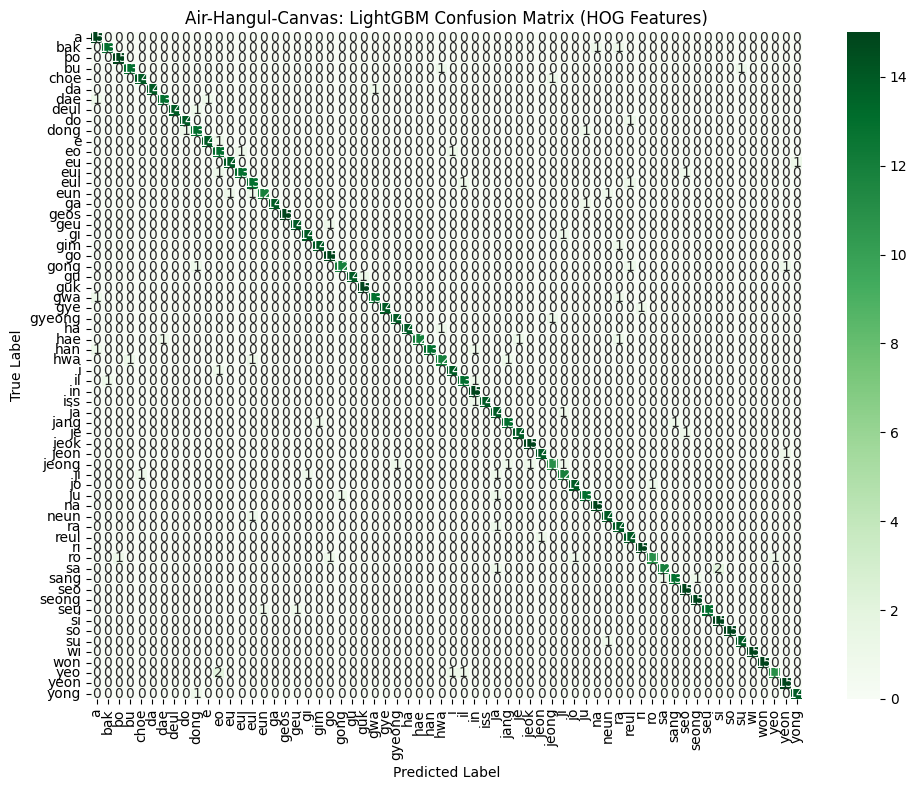

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Air-Hangul-Canvas: LightGBM Confusion Matrix (HOG Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('evaluation_lgbm_confusion_matrix.png', dpi=300)
plt.show()

## 2.3 SUPPORT VECTOR MACHINE (SVM)

In [30]:
svm_model = joblib.load("model_saved/svm_hangul_model.pkl")

In [31]:
y_pred_svm = svm_model.predict(X_test)

In [32]:
print("\n[SVM Classification Report]:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))


[SVM Classification Report]:
              precision    recall  f1-score   support

           a       1.00      1.00      1.00        15
         bak       1.00      0.93      0.97        15
          bo       1.00      1.00      1.00        15
          bu       1.00      1.00      1.00        15
        choe       1.00      1.00      1.00        15
          da       0.93      0.93      0.93        15
         dae       1.00      0.93      0.97        15
        deul       1.00      1.00      1.00        15
          do       0.88      1.00      0.94        15
        dong       0.93      0.93      0.93        15
           e       1.00      1.00      1.00        15
          eo       0.88      0.93      0.90        15
          eu       1.00      1.00      1.00        15
         eui       1.00      0.93      0.97        15
         eul       1.00      1.00      1.00        15
         eun       1.00      0.93      0.97        15
          ga       0.94      1.00      0.97        

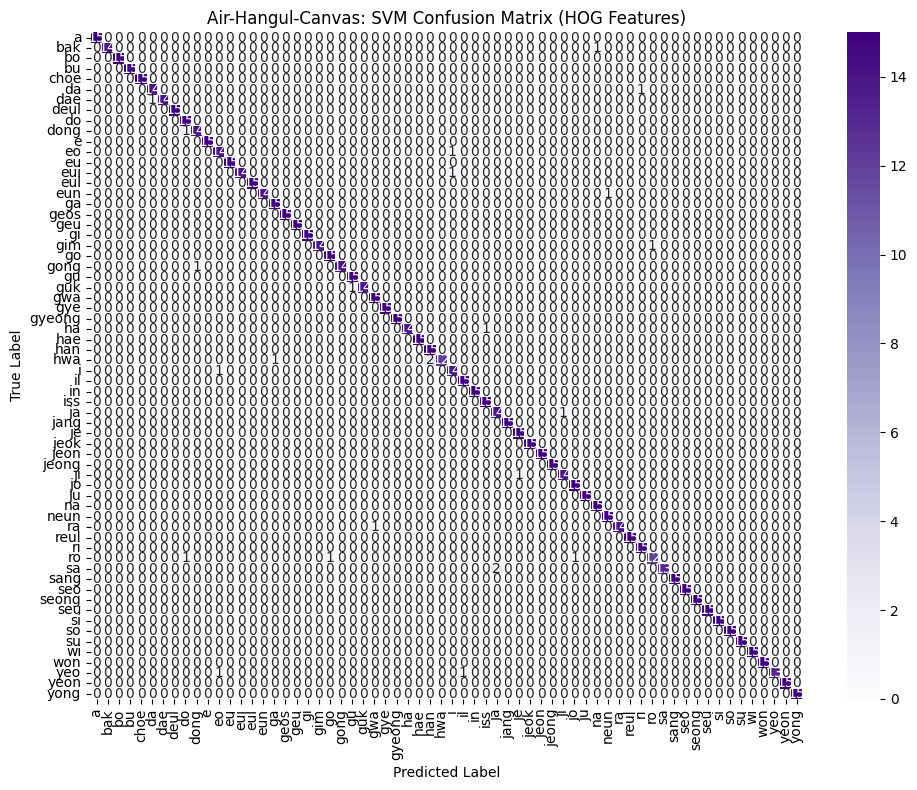

In [33]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Air-Hangul-Canvas: SVM Confusion Matrix (HOG Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('evaluation_svm_confusion_matrix.png', dpi=300)
plt.show()

# 3. Testing

In [34]:
import time
import joblib
import numpy as np

X_test = np.load('data/features_hog/X_test_hog.npy')

def profile_inference_speed(model_path, data):
    model = joblib.load(model_path)
    
    start_time = time.time()
    # Simulate processing 100 sequential characters drawn by a user
    for i in range(min(100, len(data))):
        _ = model.predict(data[i].reshape(1, -1))
    end_time = time.time()
    
    avg_latency = (end_time - start_time) / min(100, len(data)) * 1000 # convert to ms
    print(f"⏱️ {model_path} Inference Speed: {avg_latency:.2f} ms per character")

profile_inference_speed('model_saved/knn_hangul_model.pkl', X_test)
profile_inference_speed('model_saved/lgbm_hangul_model.pkl', X_test)
profile_inference_speed('model_saved/svm_hangul_model.pkl', X_test)

⏱️ model_saved/knn_hangul_model.pkl Inference Speed: 18.22 ms per character


c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Computer Vision\AOL\Air-Writing-Hangul\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Computer Vision\AOL\Air-Writing-Hangul\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Computer Vision\AOL\Air-Writing-Hangul\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Maximilanus Ronald\Documents\TUGAS NJENGG\Semester 4\Computer Vision\AOL\Air-Writing-Hangul\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X d

⏱️ model_saved/lgbm_hangul_model.pkl Inference Speed: 5.63 ms per character
⏱️ model_saved/svm_hangul_model.pkl Inference Speed: 4.75 ms per character


# Conclusion 
Based on the empirical testing of the Histogram of Oriented Gradients (HOG) features extracted from the Air-Hangul-Canvas dataset, all three machine learning classifiers achieved strong classification performance, with Support Vector Machine (SVM) emerging as the top-performing model. With svm also became the most fastest with 4.75ms 